In [20]:
!nvidia-smi
#from google.colab import drive
#drive.mount('/content/drive')
#checkpoint_dir = "/content/drive/MyDrive/tiger_assignment/checkpoints"
checkpoint_dir = "tiger_assignment/checkpoints"
import os
os.makedirs(checkpoint_dir, exist_ok=True)
#pip install sentence-transformers torch --quiet

Mon May 11 23:50:05 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 546.30                 Driver Version: 546.30       CUDA Version: 12.3     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                     TCC/WDDM  | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce RTX 3070 ...  WDDM  | 00000000:01:00.0  On |                  N/A |
| N/A   48C    P8              15W / 115W |   1543MiB /  8192MiB |     21%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [21]:
# laptop specific

import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["CUDA_MODULE_LOADING"] = "LAZY"

In [22]:
import os, json, math, random, pickle, warnings
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
from sentence_transformers import SentenceTransformer
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")

SEED = 42
torch.manual_seed(SEED); random.seed(SEED); np.random.seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

torch.backends.cudnn.benchmark = True #laptop fix - remove this
torch.backends.cuda.matmul.allow_tf32 = True #laptop fix - remove this

# ── Drive paths ───────────────────────────────────────────────────────────────
#BASE_DIR = "/content/drive/MyDrive/tiger_assignment"
BASE_DIR = "tiger_assignment"
DATA_DIR = os.path.join(BASE_DIR, "data")
EMB_DIR  = os.path.join(BASE_DIR, "embeddings")
CKPT_DIR = os.path.join(BASE_DIR, "checkpoints")
PLOT_DIR = os.path.join(BASE_DIR, "plots")
PROC_DIR = "/content/processed"   # lives in Colab RAM; fine to lose on disconnect

for d in [EMB_DIR, CKPT_DIR, PLOT_DIR, PROC_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Dataset file paths ────────────────────────────────────────────────────────
REVIEWS_PATH = os.path.join(DATA_DIR, "Toys_and_Games_5.json")
META_PATH    = os.path.join(DATA_DIR, "meta_Toys_and_Games.json")

# ── Default hyperparameters (TIGER paper defaults for Toys & Games) ───────────
DEFAULT_CONFIG = {
    "content_dim":    768,   # Sentence-T5-base output dimension
    "latent_dim":     32,
    "num_levels":     3,     # L: number of residual codebook levels
    "codebook_size":  256,   # K: entries per codebook
    "rqvae_batch":    256,
    "rqvae_lr":       1e-3,
    "rqvae_epochs":   200,
    "rqvae_patience": 20,
    "d_model":        384,   # 6 heads x 64 head_dim
    "n_heads":        6,
    "n_enc_layers":   4,
    "n_dec_layers":   4,
    "d_ff":           1024,
    "dropout":        0.1,
    "tf_batch":       128,
    "tf_lr":          1e-4,
    "tf_wd":          1e-2,
    "tf_epochs":      100,
    "tf_patience":    2,
    "beam_size":      20,
    "eval_every":      5,    # run beam-search val check every 5 epochs, not every epoch
    "train_beam_size": 5,    # use beam=5 during training val; beam=20 only for final test
    "max_enc_len":    80,    # computed at runtime: MAX_SEQ_LEN * (num_levels + 1)
    "semantic_ids":   None,  # filled at runtime
}

MAX_SEQ_LEN = 20

Device: cuda


In [23]:
def load_reviews(filepath):
    # reads the review JSON (one object per line); only needs user, item, timestamp
    records = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)
            if "reviewerID" in obj and "asin" in obj and "unixReviewTime" in obj:
                records.append({
                    "user": obj["reviewerID"],
                    "item": obj["asin"],
                    "time": int(obj["unixReviewTime"]),
                })
    print(f"Loaded {len(records):,} raw interactions")
    return records


def load_metadata(filepath):
    import ast

    meta = {}
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            try:
                obj = ast.literal_eval(line)   # <-- FIX
            except Exception:
                continue

            asin = obj.get("asin", "")
            if not asin:
                continue

            cats = obj.get("categories", [])
            if cats and isinstance(cats[0], list):
                cats = cats[0]

            meta[asin] = {
                "title": obj.get("title", ""),
                "brand": obj.get("brand", ""),
                "description": obj.get("description", ""),
                "categories": " ".join(str(c) for c in cats),
            }

    print(f"Loaded metadata for {len(meta):,} items")
    return meta


def apply_kcore(records, k=5):
    # iterative k-core: keep only users/items with >= k interactions
    # needs multiple passes because dropping one item can knock a user below k
    print(f"Applying {k}-core filtering...")
    for iteration in range(50):
        before   = len(records)
        user_cnt = defaultdict(int)
        item_cnt = defaultdict(int)
        for r in records:
            user_cnt[r["user"]] += 1
            item_cnt[r["item"]] += 1
        records = [
            r for r in records
            if user_cnt[r["user"]] >= k and item_cnt[r["item"]] >= k
        ]
        if len(records) == before:
            break
        print(f"  pass {iteration+1}: {before:,} -> {len(records):,}")
    n_users = len(set(r["user"] for r in records))
    n_items = len(set(r["item"] for r in records))
    print(f"After {k}-core: {len(records):,} interactions | {n_users:,} users | {n_items:,} items")
    return records


def build_sequences(records):
    # groups by user, sorts by timestamp, deduplicates, caps at MAX_SEQ_LEN
    user_hist = defaultdict(list)
    for r in records:
        user_hist[r["user"]].append((r["time"], r["item"]))
    sequences = {}
    for user, hist in user_hist.items():
        hist.sort(key=lambda x: x[0])
        seen  = set()
        items = []
        for _, item in hist:
            if item not in seen:
                seen.add(item)
                items.append(item)
        sequences[user] = items[-MAX_SEQ_LEN:]  # keep most recent
    sequences = {u: s for u, s in sequences.items() if len(s) >= 3}
    print(f"Built sequences for {len(sequences):,} users")
    return sequences


def split_sequences(sequences):
    # leave-one-out split (TIGER paper Section 4):
    #   train:  all items except the last two
    #   val:    predict second-to-last from everything before it
    #   test:   predict last item from all but the last
    train_seqs, val_seqs, test_seqs = {}, {}, {}
    for user, seq in sequences.items():
        train_seqs[user] = seq[:-2]
        val_seqs[user]   = (seq[:-2], seq[-2])
        test_seqs[user]  = (seq[:-1], seq[-1])
    return train_seqs, val_seqs, test_seqs


def build_item_text(item_id, meta):
    # concatenates all text fields into one string for Sentence-T5
    m     = meta.get(item_id, {})
    parts = [m.get("title",""), m.get("brand",""),
             m.get("categories",""), m.get("description","")]
    return " | ".join(p.strip() for p in parts if p.strip()) or item_id


def compute_and_cache_embeddings(item_ids, meta, cache_path):
    # encodes items with Sentence-T5 and saves to Drive — reloads on future sessions
    if os.path.exists(cache_path):
        print(f"Loading cached embeddings from {cache_path}")
        with open(cache_path, "rb") as f:
            return pickle.load(f)
    print("Computing Sentence-T5 embeddings (one-time, then cached to Drive)...")
    encoder = SentenceTransformer("sentence-transformers/sentence-t5-base", device=DEVICE)
    texts   = [build_item_text(iid, meta) for iid in item_ids]
    embs    = encoder.encode(texts, batch_size=64, show_progress_bar=True, convert_to_numpy=True)
    result  = {iid: emb for iid, emb in zip(item_ids, embs)}
    with open(cache_path, "wb") as f:
        pickle.dump(result, f)
    print(f"Embeddings saved to {cache_path}")
    return result


def run_preprocessing():
    proc_file = os.path.join(PROC_DIR, "preprocessed.pkl")
    if os.path.exists(proc_file):
        print("Loading preprocessed data from session cache...")
        with open(proc_file, "rb") as f:
            return pickle.load(f)

    records = load_reviews(REVIEWS_PATH)
    meta    = load_metadata(META_PATH)
    records = [r for r in records if r["item"] in meta]  # drop items with no text
    records = apply_kcore(records, k=5)
    seqs    = build_sequences(records)
    train_seqs, val_seqs, test_seqs = split_sequences(seqs)

    all_items = sorted(set(r["item"] for r in records))
    item2idx  = {item: i for i, item in enumerate(all_items)}
    idx2item  = {i: item for item, i in item2idx.items()}

    emb_cache       = os.path.join(EMB_DIR, "item_embeddings.pkl")
    item_embeddings = compute_and_cache_embeddings(all_items, meta, emb_cache)

    lengths = [len(s) for s in seqs.values()]
    print(f"\nSequence length stats — min={min(lengths)} | "
          f"mean={np.mean(lengths):.1f} | median={int(np.median(lengths))} | max={max(lengths)}")

    result = dict(
        train_seqs=train_seqs, val_seqs=val_seqs, test_seqs=test_seqs,
        item2idx=item2idx, idx2item=idx2item,
        item_embeddings=item_embeddings, all_items=all_items,
        n_users=len(seqs), n_items=len(all_items),
        meta=meta,
    )
    with open(proc_file, "wb") as f:
        pickle.dump(result, f)
    print("Preprocessing done.")
    return result

In [24]:
class VectorQuantizer(nn.Module):
    """
    One codebook level. Nearest-neighbour lookup with straight-through gradient.
    The straight-through trick lets gradients flow through the argmin operation
    even though it's not differentiable — the quantized vector is used on the
    forward pass, but the gradient is copied directly to the unquantized input.
    """

    def __init__(self, codebook_size, embedding_dim, commitment_cost=0.25):
        super().__init__()
        self.K                = codebook_size
        self.commitment_cost  = commitment_cost
        self.embedding        = nn.Embedding(codebook_size, embedding_dim)
        nn.init.uniform_(self.embedding.weight, -1/codebook_size, 1/codebook_size)

    def forward(self, z):
        # z: (batch, D)
        # squared distances to every codebook entry: ||z - e||^2
        dists = (
            (z**2).sum(1, keepdim=True)
            + (self.embedding.weight**2).sum(1)
            - 2 * z @ self.embedding.weight.T
        )
        indices = dists.argmin(dim=1)
        z_q     = self.embedding(indices)
        loss = (
            F.mse_loss(z_q.detach(), z)                         # codebook loss
            + self.commitment_cost * F.mse_loss(z_q, z.detach()) # commitment loss
        )
        z_q_st = z + (z_q - z).detach()  # straight-through estimator
        return z_q_st, indices, loss


class RQVAE(nn.Module):
    """
    Residual-Quantized VAE (TIGER Section 3.1).

    The encoder compresses a 768-d content embedding down to latent_dim.
    The quantizer applies L codebooks residually: each level quantizes what
    the previous level left unexplained. The decoder reconstructs the original
    content embedding from the sum of all quantized codes.

    After training we only use the encoder + quantizer to get Semantic IDs.
    The decoder is just there to provide a reconstruction signal during training.
    """

    def __init__(self, content_dim=768, hidden_dim=256, latent_dim=32,
                 num_levels=3, codebook_size=256, commitment_cost=0.25):
        super().__init__()
        self.num_levels = num_levels
        self.encoder = nn.Sequential(
            nn.Linear(content_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
        )
        self.quantizers = nn.ModuleList([
            VectorQuantizer(codebook_size, latent_dim, commitment_cost)
            for _ in range(num_levels)
        ])
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, content_dim),
        )

    def quantize(self, z):
        residual      = z
        quantized_sum = torch.zeros_like(z)
        all_indices   = []
        total_vq_loss = 0.0
        for vq in self.quantizers:
            z_q, indices, loss = vq(residual)
            quantized_sum += z_q
            residual       = residual - z_q.detach()  # pass only the unexplained part forward
            all_indices.append(indices)
            total_vq_loss += loss
        return quantized_sum, torch.stack(all_indices, dim=1), total_vq_loss

    def forward(self, x):
        z                          = self.encoder(x)
        quantized, indices, vq_loss = self.quantize(z)
        x_recon                    = self.decoder(quantized)
        recon_loss                 = F.mse_loss(x_recon, x)
        return x_recon, indices, recon_loss + vq_loss, recon_loss, vq_loss


class EmbeddingDataset(Dataset):
    def __init__(self, embeddings_dict):
        self.ids  = list(embeddings_dict.keys())
        self.embs = np.stack([embeddings_dict[k] for k in self.ids])
    def __len__(self):       return len(self.ids)
    def __getitem__(self, i): return torch.tensor(self.embs[i], dtype=torch.float32)


def train_rqvae(item_embeddings, config, tag="default"):
    """
    Trains RQ-VAE. tag namespaces checkpoints so ablation runs don't collide.
    Returns trained model and per-epoch reconstruction loss list for plotting.
    """
    dataset   = EmbeddingDataset(item_embeddings)
    loader    = DataLoader(dataset, batch_size=config["rqvae_batch"], shuffle=True)
    model     = RQVAE(
        content_dim=config["content_dim"], latent_dim=config["latent_dim"],
        num_levels=config["num_levels"], codebook_size=config["codebook_size"],
    ).to(DEVICE)
    optimizer = AdamW(model.parameters(), lr=config["rqvae_lr"], weight_decay=1e-5)
    latest_path = os.path.join(CKPT_DIR, f"rqvae_{tag}_latest.pt")
    start_epoch = 1
    if os.path.exists(latest_path):
        ckpt = torch.load(latest_path, map_location=DEVICE)
        model.load_state_dict(ckpt["model"])
        optimizer.load_state_dict(ckpt["optimizer"])
        start_epoch = ckpt["epoch"] + 1
        best_loss   = ckpt["best_loss"]
        patience    = ckpt["patience"]
        recon_hist  = ckpt["recon_hist"]
        print(f"Resuming RQ-VAE [{tag}] from epoch {start_epoch}")
    ckpt_path = os.path.join(CKPT_DIR, f"rqvae_{tag}.pt")
    best_loss = float("inf")
    patience  = 0
    recon_hist = []

    for epoch in range(start_epoch, config["rqvae_epochs"] + 1):
        model.train()
        epoch_recon    = 0.0
        used_per_level = [set() for _ in range(config["num_levels"])]

        for batch in loader:
            batch = batch.to(DEVICE)
            optimizer.zero_grad()
            _, indices, loss, recon_loss, _ = model(batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_recon += recon_loss.item()
            for lvl in range(config["num_levels"]):
                used_per_level[lvl].update(indices[:, lvl].cpu().tolist())

        avg_recon = epoch_recon / len(loader)
        recon_hist.append(avg_recon)
        usage = [len(s) for s in used_per_level]

        if epoch % 10 == 0:
            print(f"[RQ-VAE:{tag}] epoch {epoch:3d} | recon={avg_recon:.5f} | "
                  f"codebook usage: {usage}")

        if avg_recon < best_loss:
            best_loss = avg_recon
            patience  = 0
            torch.save({"epoch": epoch, "model": model.state_dict(),
                        "loss": best_loss, "usage": usage}, ckpt_path)
            torch.save({
                "epoch": epoch, "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "recon_hist": recon_hist, "best_loss": best_loss,
                "patience": patience,
            }, latest_path)
        else:
            patience += 1
            if patience >= config["rqvae_patience"]:
                print(f"Early stopping RQ-VAE at epoch {epoch}.")
                if os.path.exists(latest_path):
                    os.remove(latest_path)
                break

    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model"])
    print(f"Best RQ-VAE (epoch {ckpt['epoch']}, recon={ckpt['loss']:.5f}, usage={ckpt['usage']})")
    return model, recon_hist


def extract_semantic_ids(rqvae_model, item_embeddings, config):
    """
    Runs encoder+quantizer on every item.
    Returns dict: item_id -> tuple (c0, c1, ..., c_{L-1}, suffix)

    Collision handling: if two items get the same code tuple (c0,...,c_{L-1}),
    the decoder can't tell them apart. We append an integer suffix to each
    colliding item so every Semantic ID is unique. Items without collisions
    get suffix = -1 (represented by a NO_SUFFIX token in the vocabulary).
    """
    rqvae_model.eval()
    dataset     = EmbeddingDataset(item_embeddings)
    loader      = DataLoader(dataset, batch_size=512, shuffle=False)
    all_ids     = dataset.ids
    all_indices = []

    with torch.no_grad():
        for batch in loader:
            z = rqvae_model.encoder(batch.to(DEVICE))
            _, indices, _ = rqvae_model.quantize(z)
            all_indices.append(indices.cpu().numpy())

    all_indices  = np.concatenate(all_indices, axis=0)  # (N, L)
    seen_tuples  = defaultdict(list)
    for item_id, codes in zip(all_ids, all_indices):
        seen_tuples[tuple(codes.tolist())].append(item_id)

    semantic_ids    = {}
    suffix_counters = defaultdict(int)
    n_collisions    = 0
    for item_id, codes in zip(all_ids, all_indices):
        t = tuple(codes.tolist())
        if len(seen_tuples[t]) > 1:
            suffix = suffix_counters[t]
            suffix_counters[t] += 1
            semantic_ids[item_id] = t + (suffix,)
            n_collisions += 1
        else:
            semantic_ids[item_id] = t + (-1,)

    print(f"Semantic IDs extracted | {n_collisions} collision items | "
          f"{len(seen_tuples)} unique base tuples out of {len(all_ids)} items")
    return semantic_ids


In [25]:
def build_vocab(semantic_ids, num_levels, codebook_size):
    """
    Shared vocabulary:
      index 0          : [PAD]
      index 1          : [BOS]
      index 2          : [EOS]
      3 + lvl*K + code : codebook token for level lvl, entry code
      3 + L*K          : NO_SUFFIX (for items without collisions)
      3 + L*K + 1 + s  : suffix token s (for collision disambiguation)
    """
    PAD_ID = 0; BOS_ID = 1; EOS_ID = 2
    max_suffix   = max(
        (sid[-1] for sid in semantic_ids.values() if sid[-1] != -1), default=-1)
    NO_SUFFIX_ID = 3 + num_levels * codebook_size
    vocab_size   = NO_SUFFIX_ID + max_suffix + 2  # +1 for 0-index, +1 for NO_SUFFIX itself

    def encode_sid(sid):
        tokens = [3 + lvl * codebook_size + code for lvl, code in enumerate(sid[:-1])]
        tokens.append(NO_SUFFIX_ID if sid[-1] == -1 else NO_SUFFIX_ID + 1 + sid[-1])
        return tokens

    return {
        "vocab_size":      vocab_size,
        "PAD_ID":          PAD_ID,
        "BOS_ID":          BOS_ID,
        "EOS_ID":          EOS_ID,
        "NO_SUFFIX_ID":    NO_SUFFIX_ID,
        "encode_sid":      encode_sid,
        "tokens_per_item": num_levels + 1,  # L codebook tokens + 1 suffix
    }


class TIGERDataset(Dataset):
    """
    Encoder input:  user history flattened to Semantic ID tokens, left-padded.
    Decoder target: Semantic ID tokens of the next item (teacher-forced during training).
    """

    def __init__(self, user_seqs, semantic_ids, vocab, max_enc_len):
        self.samples = []
        encode = vocab["encode_sid"]
        PAD = vocab["PAD_ID"]; BOS = vocab["BOS_ID"]; EOS = vocab["EOS_ID"]

        for user, seq_or_pair in user_seqs.items():
            if isinstance(seq_or_pair, tuple):
                history, target = seq_or_pair
            else:
                if len(seq_or_pair) < 2:
                    continue
                history, target = seq_or_pair[:-1], seq_or_pair[-1]

            if target not in semantic_ids or not history:
                continue

            enc_tokens = []
            for item in history:
                if item in semantic_ids:
                    enc_tokens.extend(encode(semantic_ids[item]))

            # left-truncate: keep most recent context
            enc_tokens = enc_tokens[-max_enc_len:]
            enc_tokens = [PAD] * (max_enc_len - len(enc_tokens)) + enc_tokens

            dec_tokens = [BOS] + encode(semantic_ids[target]) + [EOS]

            self.samples.append({
                "enc":     torch.tensor(enc_tokens,      dtype=torch.long),
                "dec_in":  torch.tensor(dec_tokens[:-1], dtype=torch.long),
                "dec_out": torch.tensor(dec_tokens[1:],  dtype=torch.long),
                "target":  target,
            })

    def __len__(self):       return len(self.samples)
    def __getitem__(self, i): return self.samples[i]


def build_sliding_window_train(train_seqs, semantic_ids, vocab, max_enc_len):
    """
    Creates one training sample per (prefix -> next item) pair across all users,
    not just one per user. This uses the full sequence much more efficiently.
    """
    samples = {}
    for user, seq in train_seqs.items():
        for end in range(2, len(seq) + 1):
            samples[f"{user}_{end}"] = seq[:end]
    return TIGERDataset(samples, semantic_ids, vocab, max_enc_len)

In [26]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class TIGERTransformer(nn.Module):
    """
    Encoder-decoder Transformer (TIGER Section 3.2).

    The encoder reads the user's full history as a flat sequence of Semantic ID
    tokens using bidirectional attention — it sees everything at once.

    The decoder generates the target item's Semantic ID one token at a time,
    using causal (left-to-right) self-attention plus cross-attention into the
    encoder's output. This is a standard seq2seq setup.

    Weight tying: the output projection shares weights with the token embedding.
    This reduces parameter count and often helps generalisation in small-vocab models.
    """

    def __init__(self, vocab_size, d_model=384, n_heads=6, n_enc_layers=4,
                 n_dec_layers=4, d_ff=1024, dropout=0.1, max_len=512):
        super().__init__()
        self.d_model   = d_model
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_enc   = PositionalEncoding(d_model, max_len=max_len, dropout=dropout)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_enc_layers)

        dec_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, norm_first=True)
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=n_dec_layers)

        self.output_proj = nn.Linear(d_model, vocab_size)
        self.output_proj.weight = self.token_emb.weight  # weight tying
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def encode(self, src, src_key_padding_mask=None):
        x = self.pos_enc(self.token_emb(src) * math.sqrt(self.d_model))
        return self.encoder(x, src_key_padding_mask=src_key_padding_mask)

    def decode(self, tgt, memory, tgt_mask=None, memory_key_padding_mask=None):
        x = self.pos_enc(self.token_emb(tgt) * math.sqrt(self.d_model))
        return self.decoder(x, memory, tgt_mask=tgt_mask,
                            memory_key_padding_mask=memory_key_padding_mask)

    def forward(self, src, tgt, src_key_padding_mask=None):
        memory   = self.encode(src, src_key_padding_mask)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(
            tgt.size(1), device=src.device)
        dec_out  = self.decode(tgt, memory, tgt_mask=tgt_mask,
                               memory_key_padding_mask=src_key_padding_mask)
        return self.output_proj(dec_out)  # (batch, dec_len, vocab_size)

In [27]:
def get_warmup_scheduler(optimizer, warmup_steps, total_steps):
    # linear warmup for the first 10% of steps, then linear decay to 0
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        return max(0.0, (total_steps - step) / max(1, total_steps - warmup_steps))
    return LambdaLR(optimizer, lr_lambda)


def train_transformer(model, train_loader, val_loader, config, vocab,
                      semantic_ids, tag="default"):
    # semantic_ids passed explicitly so val evaluation works from epoch 1
    optimizer   = AdamW(model.parameters(), lr=config["tf_lr"], weight_decay=config["tf_wd"])
    total_steps = len(train_loader) * config["tf_epochs"]
    scheduler   = get_warmup_scheduler(optimizer, total_steps // 10, total_steps)
    criterion   = nn.CrossEntropyLoss(ignore_index=vocab["PAD_ID"])
    ckpt_path   = os.path.join(CKPT_DIR, f"transformer_{tag}.pt")
    latest_path = os.path.join(CKPT_DIR, f"transformer_{tag}_latest.pt")
    best_val    = 0.0
    patience    = 0
    loss_hist   = []
    ndcg_hist   = []   # list of (epoch, ndcg) tuples — only populated at eval epochs

    eval_every  = config.get("eval_every", 5)
    train_beam  = config.get("train_beam_size", 5)

    # build val config with correct semantic_ids and smaller beam
    val_config = dict(config)
    val_config["beam_size"]    = train_beam
    val_config["semantic_ids"] = semantic_ids  # the fix

    start_epoch = 1
    if os.path.exists(latest_path):
        ckpt = torch.load(latest_path, map_location=DEVICE)
        model.load_state_dict(ckpt["model"])
        optimizer.load_state_dict(ckpt["optimizer"])
        start_epoch = ckpt["epoch"] + 1
        best_val    = ckpt.get("best_val", 0.0)
        patience    = ckpt.get("patience", 0)
        loss_hist   = ckpt.get("loss_hist", [])
        ndcg_hist   = ckpt.get("ndcg_hist", [])
        print(f"Resuming Transformer [{tag}] from epoch {start_epoch} "
              f"(best_val={best_val:.4f}, patience={patience})")

    for epoch in range(start_epoch, config["tf_epochs"] + 1):
        model.train()
        epoch_loss = 0.0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch}", leave=False):
            enc   = batch["enc"].to(DEVICE)
            d_in  = batch["dec_in"].to(DEVICE)
            d_out = batch["dec_out"].to(DEVICE)
            mask  = (enc == vocab["PAD_ID"])
            logits = model(enc, d_in, src_key_padding_mask=mask)
            loss   = criterion(logits.reshape(-1, logits.size(-1)), d_out.reshape(-1))
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        loss_hist.append(avg_loss)

        is_first_resumed_epoch = (epoch == start_epoch and start_epoch > 1)
        if (epoch % eval_every == 0 or epoch == 1) and not is_first_resumed_epoch:
            val_met  = evaluate(model, val_loader, vocab, val_config, k_values=[10])
            val_ndcg = val_met["ndcg@10"]
            ndcg_hist.append((epoch, val_ndcg))
            print(f"[Transformer:{tag}] epoch {epoch:3d} | "
                  f"loss={avg_loss:.4f} | val_ndcg@10={val_ndcg:.4f} (beam={train_beam})")

            if val_ndcg > best_val:
                best_val = val_ndcg
                patience = 0
                torch.save({"epoch": epoch, "model": model.state_dict(),
                            "ndcg": val_ndcg}, ckpt_path)
                done_flag = os.path.join(CKPT_DIR, f"transformer_{tag}_done.flag")
                with open(done_flag, "w") as f:
                    f.write(f"epoch={epoch},ndcg={val_ndcg:.4f}")
            else:
                patience += 1
                if patience >= config["tf_patience"]:
                    print(f"Early stopping [{tag}] at epoch {epoch} "
                          f"(no improvement for {patience} checks = "
                          f"{patience * eval_every} epochs).")
                    if os.path.exists(latest_path):
                        os.remove(latest_path)
                    done_flag = os.path.join(CKPT_DIR, f"transformer_{tag}_done.flag")
                    with open(done_flag, "w") as f:
                        f.write(f"early_stop_epoch={epoch}")
                    break
        else:
            print(f"[Transformer:{tag}] epoch {epoch:3d} | loss={avg_loss:.4f}")

        # save latest state every epoch so Colab disconnects don't lose progress
        torch.save({
            "epoch": epoch, "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "best_val": best_val, "patience": patience,
            "loss_hist": loss_hist, "ndcg_hist": ndcg_hist,
        }, latest_path)

    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model"])
    print(f"Best Transformer [{tag}] loaded "
          f"(epoch {ckpt['epoch']}, val ndcg@10={ckpt['ndcg']:.4f})")

    ndcg_by_epoch = {ep: v for ep, v in ndcg_hist}
    full_ndcg = [ndcg_by_epoch.get(e) for e in range(1, len(loss_hist) + 1)]
    return model, loss_hist, full_ndcg



In [28]:
def build_token_to_item(semantic_ids, vocab):
    encode = vocab["encode_sid"]
    return {tuple(encode(sid)): iid for iid, sid in semantic_ids.items()}


def beam_search(model, enc_input, vocab, beam_size, max_dec_len, token_to_item):
    """
    Standard beam search over the Semantic ID token vocabulary.

    How full-item ranking works here:
    The beam implicitly searches over the full item vocabulary because the token
    vocabulary covers all codebook entries. Any valid Semantic ID tuple maps to
    a real item via token_to_item. We don't restrict candidates to a sampled
    subset — every item can in principle be reached by some sequence of tokens.
    This matches the TIGER paper's full-item ranking protocol.

    Beams that decode to a token sequence not in token_to_item are invalid
    (the tuple doesn't correspond to any real item). We count and report those.
    """
    PAD = vocab["PAD_ID"]; BOS = vocab["BOS_ID"]; EOS = vocab["EOS_ID"]

    with torch.no_grad():
        src_mask = (enc_input == PAD)
        memory   = model.encode(enc_input, src_key_padding_mask=src_mask)
        beams    = [(0.0, [BOS])]
        completed = []

        for _ in range(max_dec_len):
            new_beams = []
            for log_prob, tokens in beams:
                tgt      = torch.tensor([tokens], dtype=torch.long, device=DEVICE)
                tgt_mask = nn.Transformer.generate_square_subsequent_mask(
                    tgt.size(1), device=DEVICE)
                dec_out  = model.decode(tgt, memory, tgt_mask=tgt_mask,
                                        memory_key_padding_mask=src_mask)
                next_lp  = F.log_softmax(
                    model.output_proj(dec_out[:, -1, :]), dim=-1).squeeze(0)
                top_vals, top_ids = next_lp.topk(beam_size)
                for val, tid in zip(top_vals.tolist(), top_ids.tolist()):
                    new_seq = tokens + [tid]
                    (completed if tid == EOS else new_beams).append((log_prob + val, new_seq))
            new_beams.sort(key=lambda x: x[0], reverse=True)
            beams = new_beams[:beam_size]
            if not beams:
                break

        completed.extend(beams)
        completed.sort(key=lambda x: x[0], reverse=True)

    results, n_invalid, seen = [], 0, set()
    for score, tokens in completed:
        inner = tuple(t for t in tokens if t not in (BOS, EOS))
        if inner in token_to_item:
            item = token_to_item[inner]
            if item not in seen:
                seen.add(item)
                results.append((item, score))
        else:
            n_invalid += 1
    return results, n_invalid


def evaluate(model, data_loader, vocab, config, k_values=[5, 10]):
    """
    Full-item ranking evaluation, matching TIGER paper Section 4.
    No sampled negatives — the beam searches the entire item space.
    """
    model.eval()
    torch.backends.cudnn.benchmark = True #laptop fix - remove this
    token_to_item = build_token_to_item(config["semantic_ids"], vocab)
    max_dec_len   = vocab["tokens_per_item"]
    metrics       = defaultdict(list)
    total_invalid = 0
    total_queries = 0

    for batch in tqdm(data_loader, desc="Evaluating", leave=False):
        enc     = batch["enc"].to(DEVICE)
        targets = batch["target"]
        for i in range(enc.size(0)):
            candidates, n_inv = beam_search(
                model, enc[i:i+1], vocab,
                beam_size    = config["beam_size"],
                max_dec_len  = max_dec_len,
                token_to_item= token_to_item,
            )
            total_invalid += n_inv
            total_queries += 1
            rank = next(
                (pos for pos, (item, _) in enumerate(candidates, 1)
                 if item == targets[i]),
                len(candidates) + 1
            )
            for k in k_values:
                metrics[f"ndcg@{k}"].append(
                    1.0 / math.log2(rank + 1) if rank <= k else 0.0)
                metrics[f"recall@{k}"].append(1.0 if rank <= k else 0.0)

    result = {k: float(np.mean(v)) for k, v in metrics.items()}
    result["invalid_rate"] = total_invalid / max(1, total_queries * config["beam_size"])
    return result

In [29]:
PLOT_STYLE = {
    "figure.facecolor":  "#ffffff",
    "axes.facecolor":    "#f8f9fa",
    "axes.edgecolor":    "#dee2e6",
    "axes.grid":         True,
    "grid.color":        "#dee2e6",
    "grid.linewidth":    0.8,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
}


def plot_rqvae_training(recon_hist, tag="default"):
    with plt.rc_context(PLOT_STYLE):
        fig, ax = plt.subplots(figsize=(7, 4))
        epochs = range(1, len(recon_hist) + 1)
        ax.plot(epochs, recon_hist, color="#2563eb", linewidth=2, label="Recon Loss")

        # mark the best epoch
        best_ep = int(np.argmin(recon_hist)) + 1
        ax.axvline(best_ep, color="#dc2626", linestyle="--", linewidth=1,
                   label=f"Best epoch {best_ep}")
        ax.scatter([best_ep], [recon_hist[best_ep-1]], color="#dc2626", zorder=5, s=50)

        ax.set_xlabel("Epoch")
        ax.set_ylabel("MSE Reconstruction Loss")
        ax.set_title(f"RQ-VAE Training — {tag}")
        ax.legend(framealpha=0.8)
        plt.tight_layout()
        path = os.path.join(PLOT_DIR, f"rqvae_train_{tag}.png")
        plt.savefig(path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved {path}")


def plot_codebook_usage(rqvae_model, item_embeddings, config, tag="default"):
    # counts how many of the K codebook slots are actually used across all items.
    # dead codes (unused slots) = wasted capacity. ideally all K are used.
    rqvae_model.eval()
    dataset        = EmbeddingDataset(item_embeddings)
    loader         = DataLoader(dataset, batch_size=512, shuffle=False)
    used_per_level = [set() for _ in range(config["num_levels"])]
    with torch.no_grad():
        for batch in loader:
            z = rqvae_model.encoder(batch.to(DEVICE))
            _, indices, _ = rqvae_model.quantize(z)
            for lvl in range(config["num_levels"]):
                used_per_level[lvl].update(indices[:, lvl].cpu().tolist())

    counts  = [len(s) for s in used_per_level]
    dead    = [config["codebook_size"] - c for c in counts]
    levels  = [f"Level {i}" for i in range(config["num_levels"])]
    x       = np.arange(len(levels))

    with plt.rc_context(PLOT_STYLE):
        fig, ax = plt.subplots(figsize=(6, 4))
        bars_used = ax.bar(x, counts, color="#2563eb", label="Used", width=0.5)
        bars_dead = ax.bar(x, dead, bottom=counts, color="#e2e8f0",
                           label="Unused (dead codes)", width=0.5)

        ax.axhline(config["codebook_size"], color="#dc2626", linestyle="--",
                   linewidth=1, label=f"Capacity K={config['codebook_size']}")
        ax.bar_label(bars_used, labels=[f"{c}\n({c/config['codebook_size']*100:.0f}%)"
                                         for c in counts], padding=3, fontsize=8)
        ax.set_xticks(x)
        ax.set_xticklabels(levels)
        ax.set_ylabel("Codebook Entries")
        ax.set_title(f"Codebook Usage per Level — {tag}")
        ax.legend(framealpha=0.8, fontsize=9)
        ax.set_ylim(0, config["codebook_size"] * 1.2)
        plt.tight_layout()
        path = os.path.join(PLOT_DIR, f"codebook_usage_{tag}.png")
        plt.savefig(path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved {path}")
    return counts


def plot_collision_analysis(semantic_ids, config):
    # shows what fraction of items share a base code tuple with another item
    n_coll  = sum(1 for sid in semantic_ids.values() if sid[-1] != -1)
    n_clean = len(semantic_ids) - n_coll
    total   = len(semantic_ids)

    with plt.rc_context({**PLOT_STYLE, "axes.facecolor": "#ffffff"}):
        fig, (ax_pie, ax_bar) = plt.subplots(1, 2, figsize=(10, 4))

        # left: pie chart
        wedge_props = {"linewidth": 2, "edgecolor": "white"}
        ax_pie.pie(
            [n_clean, n_coll],
            labels=[f"No collision\n{n_clean} items\n({n_clean/total*100:.1f}%)",
                    f"Collision\n{n_coll} items\n({n_coll/total*100:.1f}%)"],
            colors=["#2563eb", "#f59e0b"],
            wedgeprops=wedge_props,
            startangle=90,
            textprops={"fontsize": 10},
        )
        ax_pie.set_title("Semantic ID Collisions")

        # right: bar showing per-level unique tuples vs total items
        # gives a clearer picture than the pie alone
        from collections import Counter
        prefix_counts = Counter(sid[0] for sid in semantic_ids.values())
        # how many level-0 codes are used
        n_l0 = len(prefix_counts)
        n_l01 = len(set((sid[0], sid[1]) for sid in semantic_ids.values()))
        n_full = len(set(sid[:-1] for sid in semantic_ids.values()))

        labels = ["Level-0\nunique", "Level-0,1\nunique", "Full tuple\nunique", "Total items"]
        values = [n_l0, n_l01, n_full, total]
        colors = ["#3b82f6", "#60a5fa", "#93c5fd", "#1e3a5f"]
        bars   = ax_bar.bar(labels, values, color=colors, width=0.55, edgecolor="white")
        ax_bar.bar_label(bars, fmt="%d", padding=3, fontsize=9)
        ax_bar.set_ylabel("Count")
        ax_bar.set_title(f"Unique Prefixes by Level\n(L={config['num_levels']}, K={config['codebook_size']})")
        ax_bar.set_ylim(0, total * 1.15)

        plt.suptitle("Collision Analysis", fontsize=13, fontweight="bold", y=1.01)
        plt.tight_layout()
        path = os.path.join(PLOT_DIR,
               f"collision_L{config['num_levels']}_K{config['codebook_size']}.png")
        plt.savefig(path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved {path}")


def plot_transformer_training(loss_hist, ndcg_hist, tag="default"):
    # ndcg_hist has None at epochs that weren't evaluated — filter those out
    epochs     = list(range(1, len(loss_hist) + 1))
    eval_ep    = [e for e, v in zip(epochs, ndcg_hist) if v is not None]
    eval_ndcg  = [v for v in ndcg_hist if v is not None]

    with plt.rc_context(PLOT_STYLE):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        # loss curve
        ax1.plot(epochs, loss_hist, color="#2563eb", linewidth=2)
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Cross-Entropy Loss")
        ax1.set_title(f"Training Loss — {tag}")

        # ndcg curve — only at eval epochs
        if eval_ndcg:
            ax2.plot(eval_ep, eval_ndcg, color="#d97706", linewidth=2,
                     marker="o", markersize=5, label="Val NDCG@10")
            best_idx = int(np.argmax(eval_ndcg))
            ax2.scatter([eval_ep[best_idx]], [eval_ndcg[best_idx]],
                        color="#dc2626", zorder=6, s=80,
                        label=f"Best: {eval_ndcg[best_idx]:.4f} @ ep{eval_ep[best_idx]}")
            ax2.legend(framealpha=0.8, fontsize=9)
        else:
            ax2.text(0.5, 0.5, "No eval data yet", transform=ax2.transAxes,
                     ha="center", va="center", color="#6b7280")

        ax2.set_xlabel("Epoch")
        ax2.set_ylabel("NDCG@10")
        ax2.set_title(f"Validation NDCG@10 (beam={DEFAULT_CONFIG['train_beam_size']}) — {tag}")

        plt.tight_layout()
        path = os.path.join(PLOT_DIR, f"transformer_train_{tag}.png")
        plt.savefig(path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved {path}")


def plot_ablation_bar(results_list, metric):
    labels  = [r["label"] for r in results_list]
    values  = [r.get(metric, 0.0) for r in results_list]
    # default config gets a stronger colour, ablations get lighter
    colors  = ["#1e3a5f" if "default" in r["label"] else "#60a5fa"
               for r in results_list]

    with plt.rc_context(PLOT_STYLE):
        fig, ax = plt.subplots(figsize=(9, 0.55 * len(labels) + 2))
        bars = ax.barh(labels, values, color=colors, edgecolor="white", height=0.6)
        ax.bar_label(bars, fmt="%.4f", padding=5, fontsize=9)
        ax.set_xlabel(metric.upper())
        ax.set_title(f"Ablation Study — {metric.upper()}")
        ax.invert_yaxis()
        # add a vertical line at the default value for easy comparison
        default_val = results_list[0].get(metric, 0.0)
        ax.axvline(default_val, color="#dc2626", linestyle="--",
                   linewidth=1, label="Default")
        ax.legend(fontsize=9)
        plt.tight_layout()
        path = os.path.join(PLOT_DIR, f"ablation_{metric.replace('@','_at_')}.png")
        plt.savefig(path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved {path}")

In [30]:
def run_experiment(data, config=None, tag="default"):
    """
    Runs both training stages for one config.
    Returns: (model, vocab, semantic_ids, test_metrics, histories)
    """
    if config is None:
        config = DEFAULT_CONFIG.copy()

    # recalculate max_enc_len in case num_levels changed in an ablation config
    config["max_enc_len"] = MAX_SEQ_LEN * (config["num_levels"] + 1)

    # ── Stage 1: RQ-VAE ───────────────────────────────────────────────────────
    sid_cache = os.path.join(CKPT_DIR, f"semantic_ids_{tag}.pkl")
    rqvae_model = RQVAE(
        content_dim=config["content_dim"], latent_dim=config["latent_dim"],
        num_levels=config["num_levels"], codebook_size=config["codebook_size"],
    ).to(DEVICE)

    if os.path.exists(sid_cache):
        print(f"[{tag}] Loading cached Semantic IDs...")
        with open(sid_cache, "rb") as f:
            semantic_ids = pickle.load(f)
        rqvae_hist = []
        rqvae_ckpt = os.path.join(CKPT_DIR, f"rqvae_{tag}.pt")
        if os.path.exists(rqvae_ckpt):
            rqvae_model.load_state_dict(
                torch.load(rqvae_ckpt, map_location=DEVICE)["model"])
    else:
        rqvae_model, rqvae_hist = train_rqvae(data["item_embeddings"], config, tag=tag)
        semantic_ids = extract_semantic_ids(rqvae_model, data["item_embeddings"], config)
        with open(sid_cache, "wb") as f:
            pickle.dump(semantic_ids, f)

    config["semantic_ids"] = semantic_ids

    # plots for this config's RQ-VAE stage
    if rqvae_hist:
        plot_rqvae_training(rqvae_hist, tag=tag)
    plot_codebook_usage(rqvae_model, data["item_embeddings"], config, tag=tag)
    plot_collision_analysis(semantic_ids, config)

    # ── Vocab & datasets ──────────────────────────────────────────────────────
    vocab    = build_vocab(semantic_ids, config["num_levels"], config["codebook_size"])
    print(f"[{tag}] Vocab size={vocab['vocab_size']} | tokens/item={vocab['tokens_per_item']}")

    train_ds = build_sliding_window_train(
        data["train_seqs"], semantic_ids, vocab, config["max_enc_len"])
    val_ds   = TIGERDataset(data["val_seqs"],  semantic_ids, vocab, config["max_enc_len"])
    test_ds  = TIGERDataset(data["test_seqs"], semantic_ids, vocab, config["max_enc_len"])

    train_loader = DataLoader(train_ds, batch_size=config["tf_batch"],
                              shuffle=True,  num_workers=0, pin_memory=False) #laptop fix - change False to True
    val_loader   = DataLoader(val_ds,  batch_size=config["tf_batch"], shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds, batch_size=config["tf_batch"], shuffle=False, num_workers=0)
    print(f"[{tag}] Train={len(train_ds)} | Val={len(val_ds)} | Test={len(test_ds)}")

    # ── Stage 2: Transformer ──────────────────────────────────────────────────
    model = TIGERTransformer(
        vocab_size=vocab["vocab_size"], d_model=config["d_model"],
        n_heads=config["n_heads"], n_enc_layers=config["n_enc_layers"],
        n_dec_layers=config["n_dec_layers"], d_ff=config["d_ff"],
        dropout=config["dropout"], max_len=config["max_enc_len"]+16,
    ).to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[{tag}] Transformer params: {n_params:,}")

    # FIXED — skip training if already done, load best checkpoint directly
    done_flag = os.path.join(CKPT_DIR, f"transformer_{tag}_done.flag")
    if os.path.exists(done_flag):
        print(f"[{tag}] Transformer training already complete — loading checkpoint.")
        ckpt = torch.load(os.path.join(CKPT_DIR, f"transformer_{tag}.pt"), map_location=DEVICE)
        model.load_state_dict(ckpt["model"])
        loss_hist, ndcg_hist = [], []
    else:
        model, loss_hist, ndcg_hist = train_transformer(
            model, train_loader, val_loader, config, vocab, semantic_ids, tag=tag)
    if loss_hist:
        plot_transformer_training(loss_hist, ndcg_hist, tag=tag)
    else:
        print(f"[{tag}] Skipping training plot — loaded from checkpoint.")

    # ── Test evaluation ───────────────────────────────────────────────────────
    print(f"\n[{tag}] Running test evaluation (full-item ranking via beam search)...")
    test_metrics = evaluate(model, test_loader, vocab, config, k_values=[5, 10])
    print(f"\n── [{tag}] Test Results ───────────────────────────────────")
    for k, v in test_metrics.items():
        print(f"  {k:20s}: {v:.4f}")

    # qualitative analysis only for the default run (goes in the report)
    if tag == "default":
        qualitative_semantic_analysis(
            semantic_ids, data["item_embeddings"], data["idx2item"], data["meta"])

    histories = {"rqvae_recon": rqvae_hist, "tf_loss": loss_hist, "tf_ndcg": ndcg_hist}
    return model, vocab, semantic_ids, test_metrics, histories

In [31]:
# =============================================================================
# CELL 10 — Ablation configs (Section 5 of the assignment)
#
# Required by the assignment:
#   (a) RQ-VAE codebook size K — test K = 64, 128, 256
#   (b) RQ-VAE levels L        — test L = 2, 3, 4
#   (c) Transformer architecture — vary hidden size, layers, heads
#   (d) Beam size              — test beam = 10 vs 20
#
# The default config (L=3, K=256, d=384, beam=20) is already run in Cell 11
# and is included as the first row in the ablation table automatically.
# The configs below are the additional runs you need.
#
# IMPORTANT: Each ablation run retrains both RQ-VAE and Transformer.
# On a T4 GPU, each config takes roughly 1-3 hours depending on early stopping.
# Plan for at least one full Colab session per ablation run.
# =============================================================================

ABLATION_CONFIGS = [
    # ── (a) Codebook size K ───────────────────────────────────────────────────
    # Tests whether a larger codebook gives better Semantic IDs or just wastes capacity.
    # K=256 is the default — already done.
    ("K=64,  L=3",   {"codebook_size": 64,  "num_levels": 3}),
    ("K=128, L=3",   {"codebook_size": 128, "num_levels": 3}),

    # ── (b) Number of residual levels L ──────────────────────────────────────
    # More levels = finer-grained Semantic IDs but longer sequences for the Transformer.
    # L=3 is the default — already done.
    ("K=256, L=2",   {"codebook_size": 256, "num_levels": 2}),
    ("K=256, L=4",   {"codebook_size": 256, "num_levels": 4}),

    # ── (c) Transformer architecture ─────────────────────────────────────────
    # head_dim must stay at 64, so n_heads = d_model // 64.
    # Smaller model: fewer parameters, faster but may underfit.
    ("d=256, heads=4, layers=4", {
        "d_model": 256, "n_heads": 4, "n_enc_layers": 4, "n_dec_layers": 4}),
    # Deeper model: more capacity, may help with larger datasets.
    ("d=384, heads=6, layers=6", {
        "d_model": 384, "n_heads": 6, "n_enc_layers": 6, "n_dec_layers": 6}),

    # ── (d) Beam size ─────────────────────────────────────────────────────────
    # Smaller beam = fewer candidates, faster but may miss the true item more often.
    # beam=20 is the default — already done.
    ("beam=10, d=384",  {"beam_size": 10}),
]


def run_ablation_study(data, default_test_metrics):
    results_cache_path = os.path.join(CKPT_DIR, "ablation_results.pkl")

    if os.path.exists(results_cache_path):
        with open(results_cache_path, "rb") as f:
            all_results = pickle.load(f)
        done_labels = {r["label"] for r in all_results}
        print(f"Resuming ablation — already done: {done_labels}")
    else:
        all_results = []
        done_labels = set()
        default_row = dict(default_test_metrics)
        default_row["label"] = "K=256, L=3, d=384, beam=20 (default)"
        all_results.append(default_row)
        done_labels.add(default_row["label"])

    for label, overrides in ABLATION_CONFIGS:
        if label in done_labels:
            print(f"Skipping '{label}' — already done.")
            continue

        print(f"\n{'='*60}\nAblation: {label}\n{'='*60}")
        cfg      = DEFAULT_CONFIG.copy()
        cfg.update(overrides)
        safe_tag = label.replace(" ", "_").replace("=", "").replace(",", "")
        _, _, _, metrics, _ = run_experiment(data, config=cfg, tag=safe_tag)
        metrics["label"] = label
        all_results.append(metrics)
        done_labels.add(label)

        with open(results_cache_path, "wb") as f:
            pickle.dump(all_results, f)
        print(f"Progress saved ({len(all_results)-1}/{len(ABLATION_CONFIGS)} ablations done)")

    print("\n── Ablation Results ──────────────────────────────────────────────────────")
    header = f"{'Config':<40} {'R@5':>7} {'R@10':>7} {'N@5':>7} {'N@10':>7} {'Inv%':>6}"
    print(header)
    print("-" * len(header))
    for r in all_results:
        print(f"{r['label']:<40} "
              f"{r.get('recall@5',0):>7.4f} "
              f"{r.get('recall@10',0):>7.4f} "
              f"{r.get('ndcg@5',0):>7.4f} "
              f"{r.get('ndcg@10',0):>7.4f} "
              f"{r.get('invalid_rate',0)*100:>5.1f}%")

    for metric in ["ndcg@5", "ndcg@10", "recall@5", "recall@10"]:
        plot_ablation_bar(all_results, metric)

    # ── Save results to CSV so you can plot anytime without rerunning ──────────
    import csv
    csv_path = os.path.join(CKPT_DIR, "ablation_results.csv")
    fieldnames = ["label", "recall@5", "recall@10", "ndcg@5", "ndcg@10", "invalid_rate"]
    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for r in all_results:
            writer.writerow({k: r.get(k, 0) for k in fieldnames})
    print(f"Results saved to {csv_path}")

    # ── Grouped bar chart: all 4 metrics side by side per config ──────────────
    labels  = [r["label"] for r in all_results]
    metrics_to_plot = ["recall@5", "recall@10", "ndcg@5", "ndcg@10"]
    x       = np.arange(len(labels))
    width   = 0.2
    colors  = ["#1e3a5f", "#2563eb", "#60a5fa", "#93c5fd"]

    with plt.rc_context(PLOT_STYLE):
        fig, ax = plt.subplots(figsize=(14, 5))
        for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
            vals = [r.get(metric, 0) for r in all_results]
            bars = ax.bar(x + i * width, vals, width, label=metric.upper(),
                          color=color, edgecolor="white")

        ax.set_xticks(x + width * 1.5)
        ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=8)
        ax.set_ylabel("Score")
        ax.set_title("Ablation Study — All Metrics Comparison")
        ax.legend(framealpha=0.8)
        ax.grid(True, axis="y", alpha=0.3)
        plt.tight_layout()
        path = os.path.join(PLOT_DIR, "ablation_all_metrics.png")
        plt.savefig(path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved {path}")

    # ── Invalid rate bar chart ─────────────────────────────────────────────────
    with plt.rc_context(PLOT_STYLE):
        fig, ax = plt.subplots(figsize=(9, 0.55 * len(labels) + 2))
        inv_vals = [r.get("invalid_rate", 0) * 100 for r in all_results]
        colors_inv = ["#1e3a5f" if "default" in r["label"] else "#f59e0b"
                      for r in all_results]
        bars = ax.barh(labels, inv_vals, color=colors_inv, edgecolor="white", height=0.6)
        ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=9)
        ax.set_xlabel("Invalid Generation Rate (%)")
        ax.set_title("Invalid Generation Rate by Config")
        ax.invert_yaxis()
        ax.grid(True, axis="x", alpha=0.3)
        plt.tight_layout()
        path = os.path.join(PLOT_DIR, "ablation_invalid_rate.png")
        plt.savefig(path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved {path}")
    return all_results

In [32]:
data = run_preprocessing()

import json
done_flag = os.path.join(CKPT_DIR, "transformer_default_done.flag")
if os.path.exists(done_flag):
    print("Default experiment already complete — loading saved results.")
    with open(os.path.join(CKPT_DIR, "default_test_metrics.json")) as f:
        test_metrics = json.load(f)
    print(test_metrics)
else:
    model, vocab, semantic_ids, test_metrics, histories = run_experiment(
        data, config=None, tag="default")
    with open(os.path.join(CKPT_DIR, "default_test_metrics.json"), "w") as f:
        json.dump(test_metrics, f, indent=2)
    with open(os.path.join(CKPT_DIR, "transformer_default_done.flag"), "w") as f:
        f.write("done")
    print("Default experiment complete — results saved.")

Loading preprocessed data from session cache...
Default experiment already complete — loading saved results.
{'ndcg@5': 0.0245, 'ndcg@10': 0.0292, 'recall@5': 0.0342, 'recall@10': 0.0488, 'invalid_rate': 0.0238}


Resuming ablation — already done: {'K=64,  L=3', 'K=128, L=3', 'd=256, heads=4, layers=4', 'K=256, L=2', 'K=256, L=3, d=384, beam=20 (default)', 'K=256, L=4', 'd=384, heads=6, layers=6'}
Skipping 'K=64,  L=3' — already done.
Skipping 'K=128, L=3' — already done.
Skipping 'K=256, L=2' — already done.
Skipping 'K=256, L=4' — already done.
Skipping 'd=256, heads=4, layers=4' — already done.
Skipping 'd=384, heads=6, layers=6' — already done.

Ablation: beam=10, d=384
[beam10_d384] Loading cached Semantic IDs...


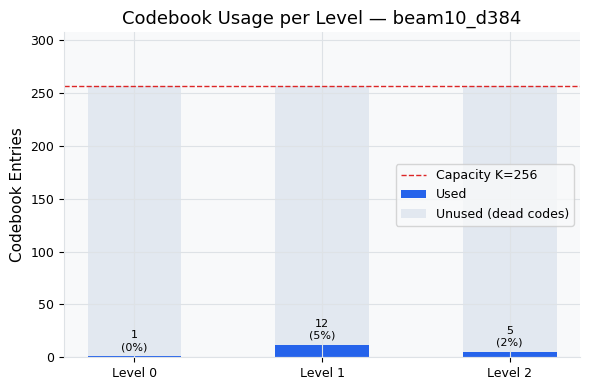

Saved tiger_assignment\plots\codebook_usage_beam10_d384.png


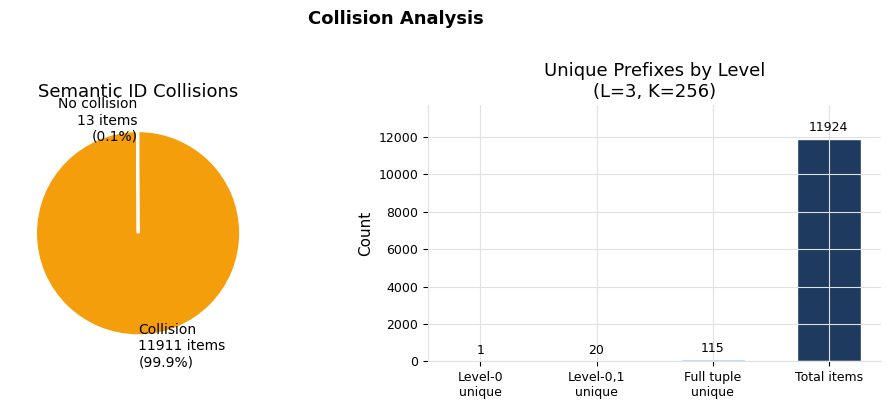

Saved tiger_assignment\plots\collision_L3_K256.png
[beam10_d384] Vocab size=1673 | tokens/item=4
[beam10_d384] Train=95582 | Val=19412 | Test=19412
[beam10_d384] Transformer params: 14,058,505
[beam10_d384] Transformer training already complete — loading checkpoint.
[beam10_d384] Skipping training plot — loaded from checkpoint.

[beam10_d384] Running test evaluation (full-item ranking via beam search)...



── [beam10_d384] Test Results ───────────────────────────────────
  ndcg@5              : 0.0242
  recall@5            : 0.0334
  ndcg@10             : 0.0309
  recall@10           : 0.0552
  invalid_rate        : 0.0039
Progress saved (7/7 ablations done)

── Ablation Results ──────────────────────────────────────────────────────
Config                                       R@5    R@10     N@5    N@10   Inv%
-------------------------------------------------------------------------------
K=256, L=3, d=384, beam=20 (default)      0.0342  0.0488  0.0245  0.0292   2.4%
K=64,  L=3                                0.0041  0.0070  0.0029  0.0038 120.5%
K=128, L=3                                0.0034  0.0071  0.0024  0.0036 120.2%
K=256, L=2                                0.0014  0.0021  0.0009  0.0011 101.6%
K=256, L=4                                0.0007  0.0012  0.0003  0.0005 124.9%
d=256, heads=4, layers=4                  0.0345  0.0472  0.0250  0.0291  34.4%
d=384, heads=6, layers=6  

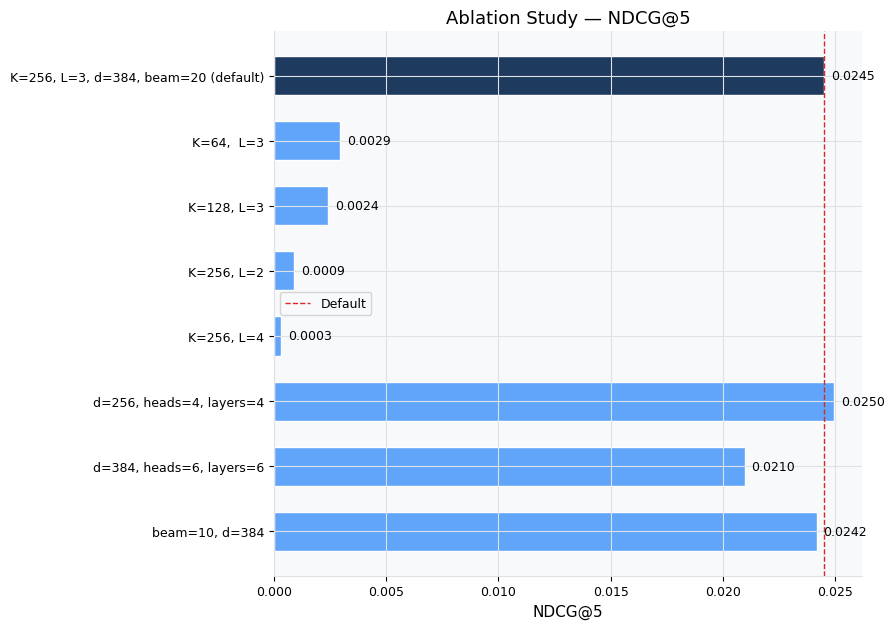

Saved tiger_assignment\plots\ablation_ndcg_at_5.png


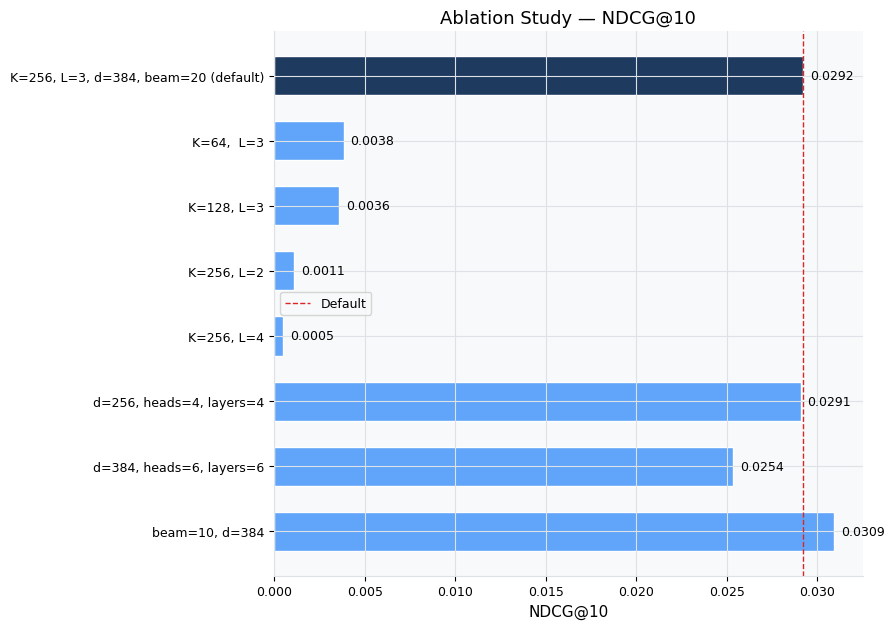

Saved tiger_assignment\plots\ablation_ndcg_at_10.png


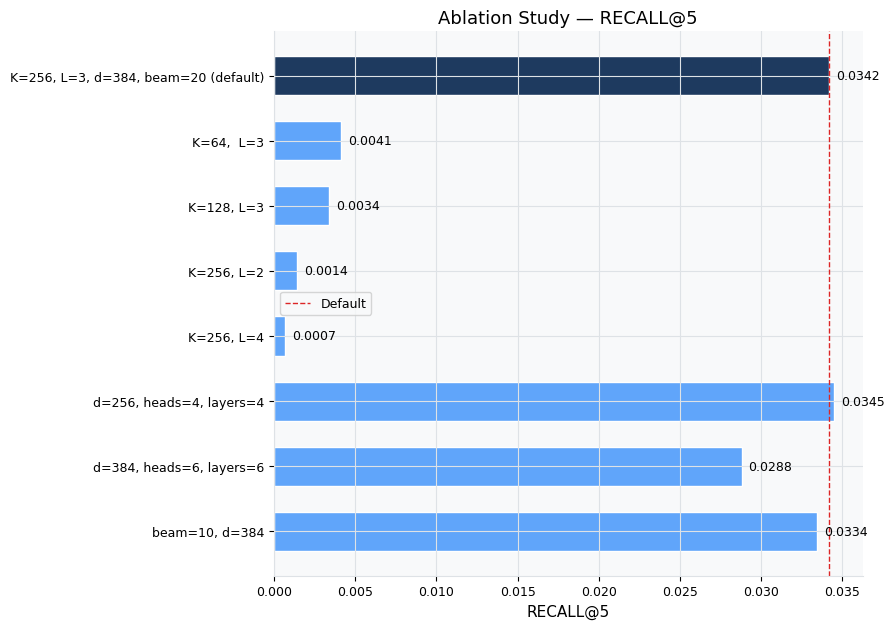

Saved tiger_assignment\plots\ablation_recall_at_5.png


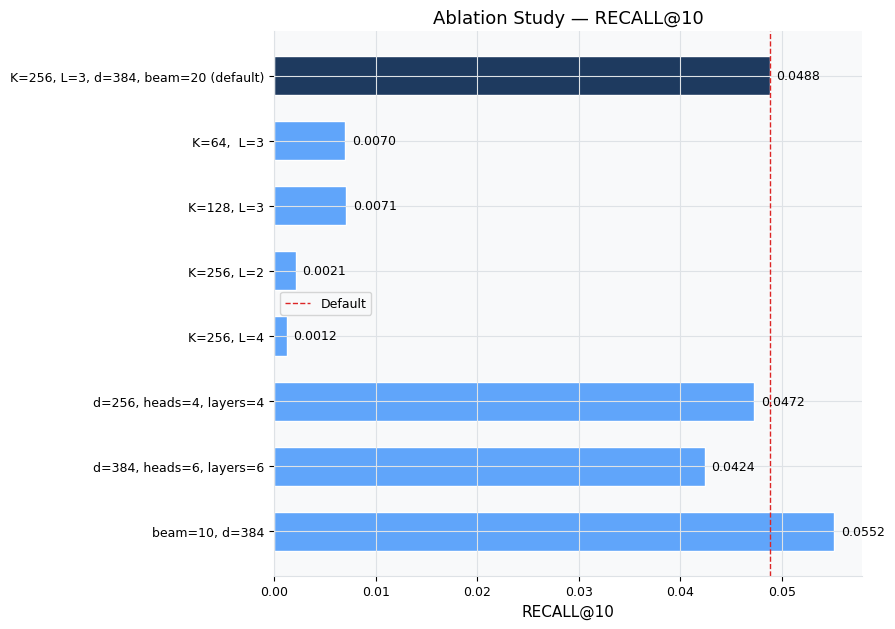

Saved tiger_assignment\plots\ablation_recall_at_10.png
Results saved to tiger_assignment\checkpoints\ablation_results.csv


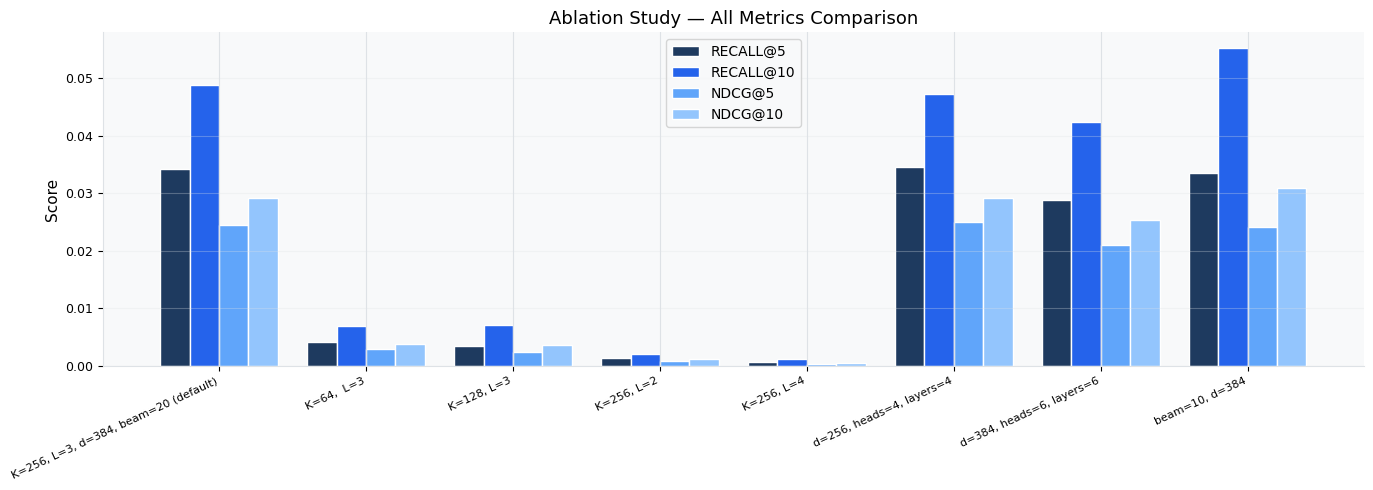

Saved tiger_assignment\plots\ablation_all_metrics.png


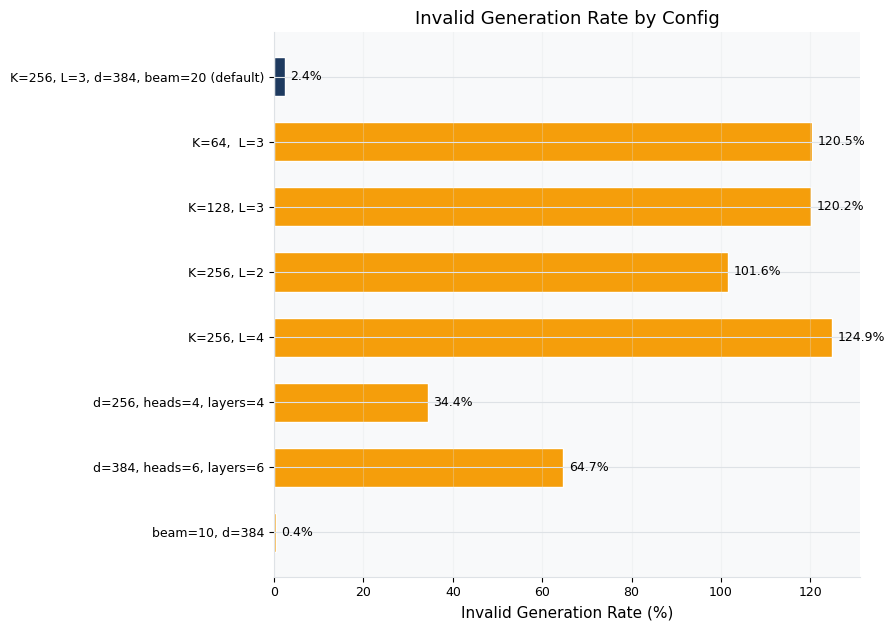

Saved tiger_assignment\plots\ablation_invalid_rate.png


In [36]:
import glob, shutil

# Auto-fix any flags that landed in the wrong folder
misplaced = glob.glob("/content/drive/MyDrive/tiger_assignment/*.flag")
for f in misplaced:
    correct = os.path.join(CKPT_DIR, os.path.basename(f))
    shutil.move(f, correct)
    print(f"Moved flag: {os.path.basename(f)} → checkpoints/")
ablation_results = run_ablation_study(data, test_metrics)